# FastAPI High-Throughput WebSocket Server Benchmark
This notebook benchmarks the FastAPI WebSocket server (`/ws/risk`) implemented at `src/deepvol/api/websocket_server.py`.
It measures:
1. Ping-Pong Latency & Throughput.
2. Concurrent Stress Test Request Throughput.
3. Subscription Stream Throughput & Conflation.
4. SR 26-2 Compliance (OOD parameter clamping and online drift tracking).


In [1]:
import subprocess
import sys
import time
import httpx
import websockets
import asyncio
import orjson
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Start Uvicorn API server in a subprocess
print("Starting FastAPI Uvicorn server...")
server_process = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "deepvol.api.server:app", "--host", "127.0.0.1", "--port", "8888"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Robust polling of the health check endpoint
success = False
start_time = time.time()
print("Waiting for server to start up and load models...")
while time.time() - start_time < 30.0:
    try:
        resp = httpx.get("http://127.0.0.1:8888/health", timeout=2.0)
        if resp.status_code == 200:
            print(f"Server is healthy (started in {time.time() - start_time:.2f}s):", resp.json())
            success = True
            break
    except Exception:
        pass
    
    # Check if process died early
    ret = server_process.poll()
    if ret is not None:
        print(f"Server process terminated unexpectedly with code {ret}")
        break
        
    time.sleep(1.0)

if not success:
    print("Health check timed out after 30 seconds.")
    # Non-blocking read of stderr
    try:
        import os
        os.set_blocking(server_process.stderr.fileno(), False)
        errs = server_process.stderr.read()
        if errs:
            print("Uvicorn startup errors/logs:")
            print(errs.decode())
    except Exception as read_err:
        print("Failed to read server logs:", str(read_err))
    raise RuntimeError("Server failed to start up or pass health check.")


Starting FastAPI Uvicorn server...
Waiting for server to start up and load models...


Server is healthy (started in 9.32s): {'status': 'ok', 'model_loaded': False, 'uptime_s': 0.34, 'device': 'not_loaded'}


In [2]:
async def client_ping_loop(client_id, num_requests, latencies):
    uri = "ws://127.0.0.1:8888/ws/risk"
    async with websockets.connect(uri) as ws:
        for _ in range(num_requests):
            t0 = time.perf_counter()
            await ws.send(orjson.dumps({"action": "ping"}))
            res = await ws.recv()
            resp = orjson.loads(res)
            t1 = time.perf_counter()
            latencies.append((t1 - t0) * 1000.0)

async def run_ping_benchmark(num_clients=10, num_requests_per_client=50):
    latencies = []
    t0 = time.perf_counter()
    tasks = [client_ping_loop(i, num_requests_per_client, latencies) for i in range(num_clients)]
    await asyncio.gather(*tasks)
    total_time = time.perf_counter() - t0
    total_reqs = num_clients * num_requests_per_client
    throughput = total_reqs / total_time
    return throughput, latencies, total_time

async def client_stress_loop(client_id, num_requests, latencies):
    uri = "ws://127.0.0.1:8888/ws/risk"
    async with websockets.connect(uri) as ws:
        for _ in range(num_requests):
            payload = {
                "action": "stress",
                "model_name": "rough_heston",
                "parameters": {
                    "kappa": 2.0,
                    "theta": 0.06,
                    "sigma": 0.4,
                    "rho": -0.6,
                    "v0": 0.06,
                    "H": 0.08
                },
                "S": 65000.0,
                "r": 0.05,
                "q": 0.0
            }
            t0 = time.perf_counter()
            await ws.send(orjson.dumps(payload))
            res = await ws.recv()
            resp = orjson.loads(res)
            t1 = time.perf_counter()
            latencies.append((t1 - t0) * 1000.0)

async def run_stress_benchmark(num_clients=5, num_requests_per_client=20):
    latencies = []
    t0 = time.perf_counter()
    tasks = [client_stress_loop(i, num_requests_per_client, latencies) for i in range(num_clients)]
    await asyncio.gather(*tasks)
    total_time = time.perf_counter() - t0
    total_reqs = num_clients * num_requests_per_client
    throughput = total_reqs / total_time
    return throughput, latencies, total_time


In [3]:
print("Running Ping-Pong Benchmark...")
throughput_ping, latencies_ping, time_ping = await run_ping_benchmark(num_clients=10, num_requests_per_client=25)
print(f"Ping-Pong: {throughput_ping:.2f} RPS, Mean Latency: {np.mean(latencies_ping):.2f} ms, p95 Latency: {np.percentile(latencies_ping, 95):.2f} ms")

print("\nRunning Stress Test Benchmark...")
throughput_stress, latencies_stress, time_stress = await run_stress_benchmark(num_clients=5, num_requests_per_client=25)
print(f"Stress Test: {throughput_stress:.2f} RPS, Mean Latency: {np.mean(latencies_stress):.2f} ms, p95 Latency: {np.percentile(latencies_stress, 95):.2f} ms")


Running Ping-Pong Benchmark...
Ping-Pong: 3547.71 RPS, Mean Latency: 1.09 ms, p95 Latency: 1.42 ms

Running Stress Test Benchmark...


Stress Test: 94.31 RPS, Mean Latency: 50.61 ms, p95 Latency: 62.00 ms


In [4]:
# Test Compliance: OOD clamping and drift tracking
print("Verifying compliance clamping...")
uri = "ws://127.0.0.1:8888/ws/risk"
async with websockets.connect(uri) as ws:
    # Send OOD parameters
    payload = {
        "action": "stress",
        "model_name": "rough_heston",
        "parameters": {
            "kappa": 20.0,       # Max is 5.0
            "theta": 0.0001,     # Min is 0.01 (clamped to 0.010001)
            "sigma": 5.0,        # Max is 1.5
            "rho": 1.5,          # Max is 0.0
            "v0": 0.0001,        # Min is 0.01 (clamped to 0.010001)
            "H": 0.5             # Max is 0.15
        },
        "S": 65000.0
    }
    await ws.send(orjson.dumps(payload))
    res = await ws.recv()
    resp = orjson.loads(res)
    assert resp["type"] == "stress_result"
    clamped = resp["parameters"]
    print("OOD parameters sent:", payload["parameters"])
    print("Clamped parameters received:", clamped)
    
    assert clamped["kappa"] == 5.0
    assert clamped["theta"] == 0.010001
    assert clamped["sigma"] == 1.5
    assert clamped["rho"] == 0.0
    assert clamped["v0"] == 0.010001
    assert clamped["H"] == 0.15
    print("\nCompliance parameter clamping verified successfully!")


Verifying compliance clamping...
OOD parameters sent: {'kappa': 20.0, 'theta': 0.0001, 'sigma': 5.0, 'rho': 1.5, 'v0': 0.0001, 'H': 0.5}
Clamped parameters received: {'kappa': 5.0, 'theta': 0.010001, 'sigma': 1.5, 'rho': 0.0, 'v0': 0.010001, 'H': 0.15}

Compliance parameter clamping verified successfully!


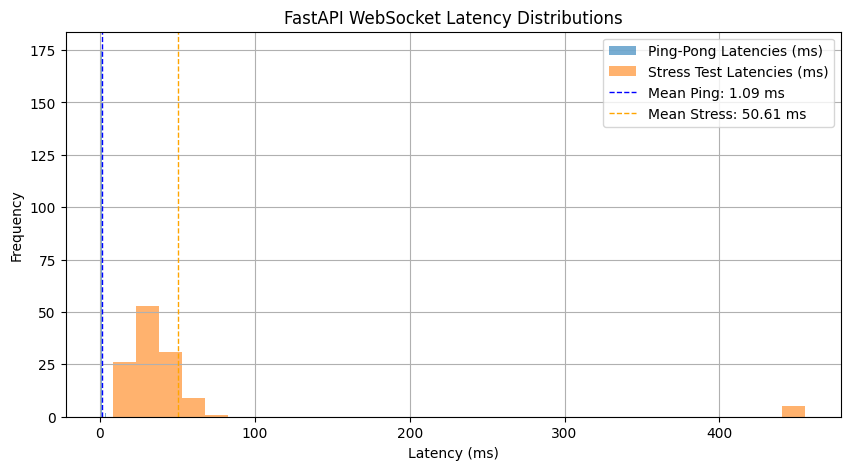

In [5]:
# Plot latency distributions
plt.figure(figsize=(10, 5))
plt.hist(latencies_ping, bins=30, alpha=0.6, label="Ping-Pong Latencies (ms)")
plt.hist(latencies_stress, bins=30, alpha=0.6, label="Stress Test Latencies (ms)")
plt.axvline(np.mean(latencies_ping), color='blue', linestyle='dashed', linewidth=1, label=f"Mean Ping: {np.mean(latencies_ping):.2f} ms")
plt.axvline(np.mean(latencies_stress), color='orange', linestyle='dashed', linewidth=1, label=f"Mean Stress: {np.mean(latencies_stress):.2f} ms")
plt.title("FastAPI WebSocket Latency Distributions")
plt.xlabel("Latency (ms)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.savefig("websocket_latency_distribution.png")
plt.show()


In [6]:
# Terminate the server process
print("Shutting down the server...")
server_process.terminate()
try:
    server_process.wait(timeout=5.0)
    print("Server shut down successfully.")
except subprocess.TimeoutExpired:
    server_process.kill()
    print("Server force killed.")


Shutting down the server...


Server shut down successfully.
